In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [6]:
master_df = pd.read_csv("master_df_final.csv")
master_df.head()

,ID,Question,QuestionText,Topic,ValidResponse,BeforeNumber,BeforeResponse,AfterNumber,AfterResponse,GROUP,...,run_0,run_1,run_2,run_3,run_4,run_5,run_6,run_7,run_8,run_9
0,0,Q1,How poorly or well would you say the system of...,Democracy,True,5,In the middle,9,Very strongly favor,1,...,6,6,4,6,4,4,6,4,6,6
1,17,Q1,How poorly or well would you say the system of...,Democracy,True,7,Moderately favor,9,Very strongly favor,1,...,6,6,8,6,6,6,6,6,6,6
2,127,Q1,How poorly or well would you say the system of...,Democracy,True,5,In the middle,7,Moderately favor,1,...,6,6,4,6,4,4,4,6,6,6
3,173,Q1,How poorly or well would you say the system of...,Democracy,True,6,Slightly favor,7,Moderately favor,1,...,5,7,7,7,7,5,7,5,7,7
4,189,Q1,How poorly or well would you say the system of...,Democracy,True,7,Moderately favor,9,Very strongly favor,1,...,6,6,8,6,8,6,6,6,6,8


In [8]:
# filter rows where before and after responses in the real data were not 0-10 inclusive
# the llm run responses are always in that range
master_df = master_df[master_df['BeforeNumber'].between(0, 10) & master_df['AfterNumber'].between(0, 10)]

In [15]:
master_df['delta_observed'] = master_df['AfterNumber'] - master_df['BeforeNumber']
for seed in range(0,10):
    col_name = f"run_{seed}"
    delta_name = f"delta_{seed}"
    delta_diff_name = f"delta_diff_{seed}"
    master_df[delta_name] = master_df[col_name] - master_df['BeforeNumber']
    master_df[delta_diff_name] = master_df[delta_name] - master_df['delta_observed']

In [16]:
# calculate mean and std deviation of deltas for runs 
master_df["delta_mean_llm"] = master_df[[f"delta_{seed}" for seed in range(0,10)]].mean(axis=1)
master_df["delta_stf_llm"] = master_df[[f"delta_{seed}" for seed in range(0,10)]].std(axis=1)

In [19]:
master_df.columns

Index(['ID', 'Question', 'QuestionText', 'Topic', 'ValidResponse',
       'BeforeNumber', 'BeforeResponse', 'AfterNumber', 'AfterResponse',
       'GROUP', 'RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER',
       'AGE', 'run_0', 'run_1', 'run_2', 'run_3', 'run_4', 'run_5', 'run_6',
       'run_7', 'run_8', 'run_9', 'delta_observed', 'delta_0', 'delta_1',
       'delta_2', 'delta_3', 'delta_4', 'delta_5', 'delta_6', 'delta_7',
       'delta_8', 'delta_9', 'delta_mean_llm', 'delta_stf_llm', 'delta_diff_0',
       'delta_diff_1', 'delta_diff_2', 'delta_diff_3', 'delta_diff_4',
       'delta_diff_5', 'delta_diff_6', 'delta_diff_7', 'delta_diff_8',
       'delta_diff_9'],
      dtype='object')

In [36]:
# i want long format, with columns: Question, seed, delta_diff
id_vars = ['ID', 'Question', 'QuestionText', 'Topic', 'ValidResponse',
       'BeforeNumber', 'BeforeResponse', 'AfterNumber', 'AfterResponse',
       'GROUP', 'RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']
long_df = pd.melt(master_df, id_vars=id_vars, value_vars=[f"delta_diff_{seed}" for seed in range(0,10)], var_name='Seed', value_name='DeltaDiff')

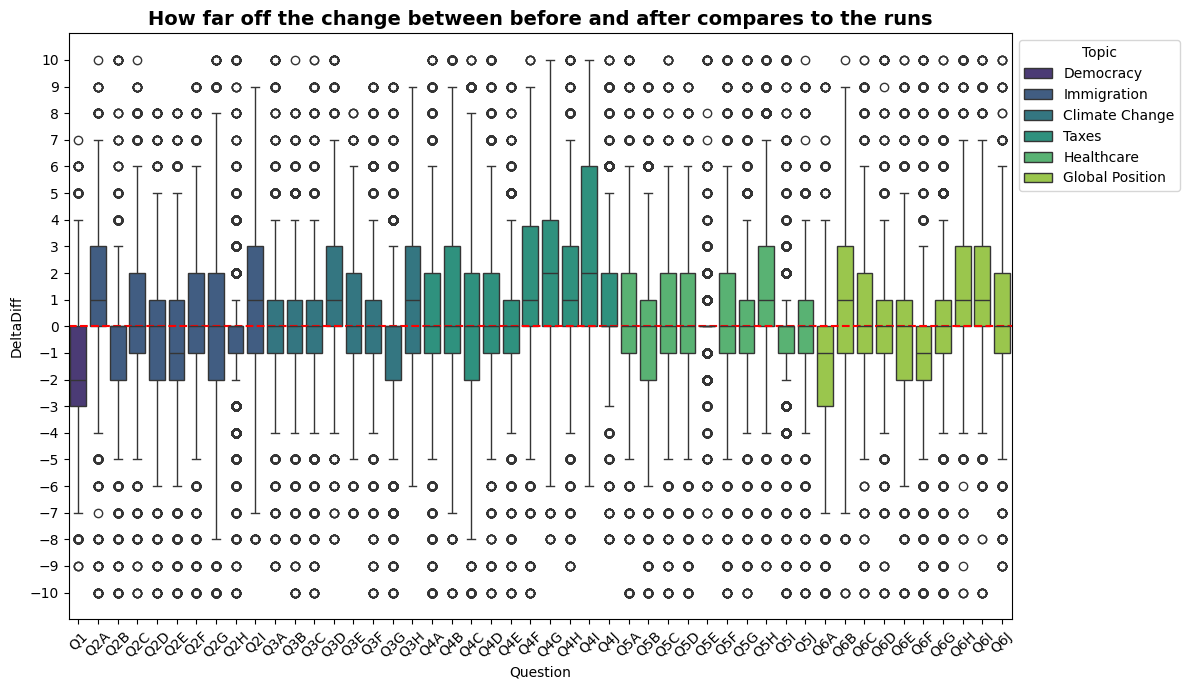

In [59]:
# i want subplots for each temperature
plt.figure(figsize=(12, 7))
sns.boxplot(data=long_df, x='Question', y='DeltaDiff', hue='Topic', palette='viridis')
plt.title('How far off the change between before and after compares to the runs', fontsize=14, fontweight='bold')
sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1))
plt.axhline(0, color='red', linestyle='--')
plt.xticks(rotation=45)
plt.yticks(np.arange(-10,11,1))
plt.tight_layout()

In [52]:
sumdf = long_df.groupby(['ID','Question',"Topic"])['DeltaDiff'].agg(['mean','std']).reset_index()

In [54]:
sumdf.head()

,ID,Question,Topic,mean,std
0,0,Q1,Democracy,-3.8,1.032796
1,0,Q2A,Immigration,-2.0,0.000000
2,0,Q2B,Immigration,-0.3,0.483046
3,0,Q2C,Immigration,-4.9,1.370320
4,0,Q2D,Immigration,-4.0,0.000000


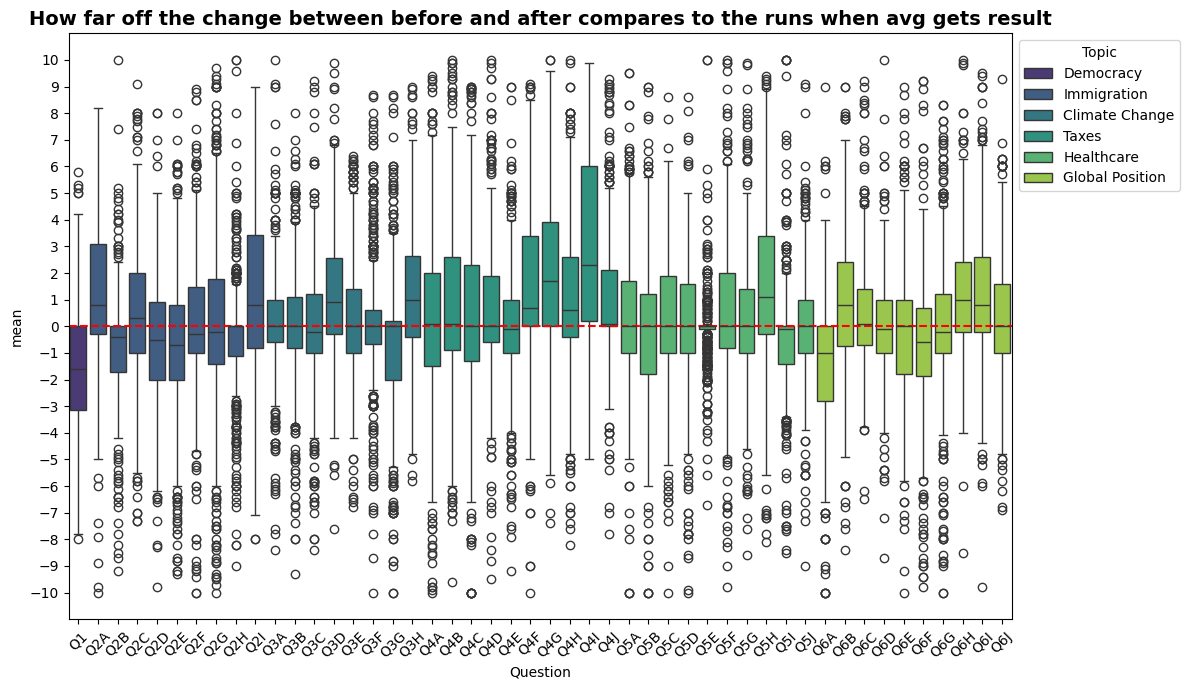

In [62]:
# i want subplots for each temperature
plt.figure(figsize=(12, 7))
sns.boxplot(data=sumdf, x='Question', y='mean', hue='Topic', palette='viridis')
plt.title('How far off the change between before and after compares to the runs when avg gets result', fontsize=14, fontweight='bold')
plt.axhline(0, color='red', linestyle='--')
sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.yticks(np.arange(-10,11,1))
plt.tight_layout()

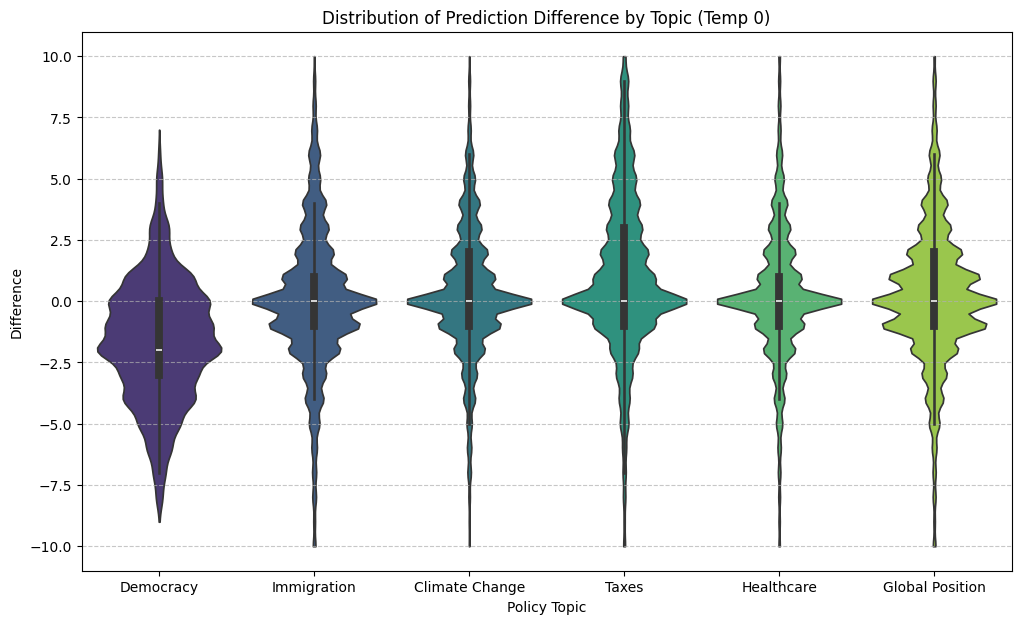

In [63]:
## do this and compare for each temperature
plt.figure(figsize=(12, 7))
sns.violinplot(data=long_df, x='Topic', y='DeltaDiff', hue='Topic', palette='viridis', cut=0)
plt.title('Distribution of Prediction Difference by Topic (Temp 0)')
plt.xlabel('Policy Topic')
plt.ylabel('Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

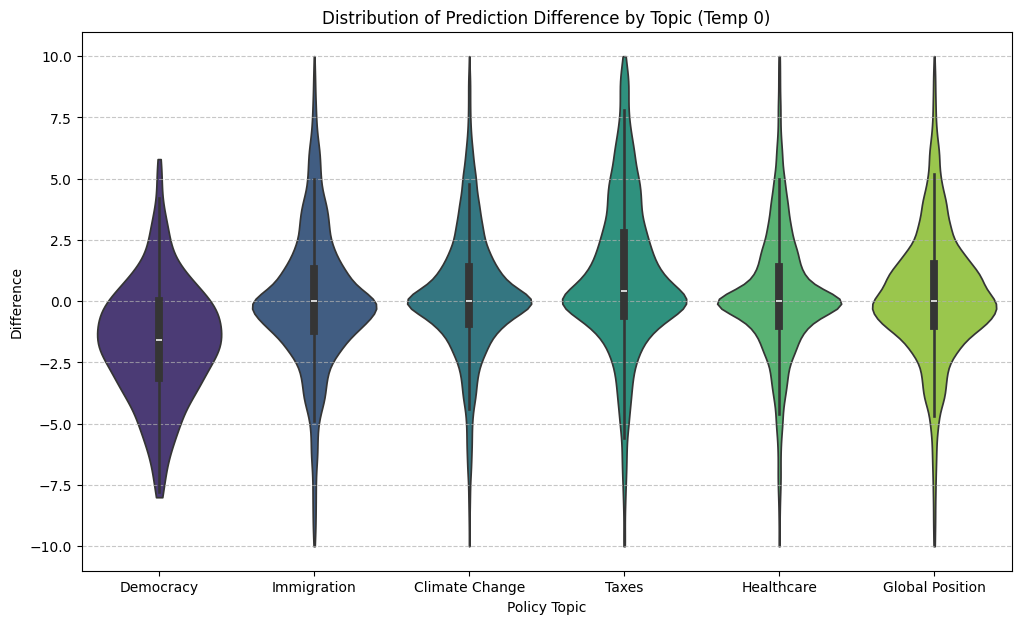

In [64]:
## do this and compare for each temperature
plt.figure(figsize=(12, 7))
sns.violinplot(data=sumdf, x='Topic', y='mean', hue='Topic', palette='viridis', cut=0)
plt.title('Distribution of Prediction Difference by Topic (Temp 0)')
plt.xlabel('Policy Topic')
plt.ylabel('Difference')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [65]:
master_df.to_csv("master_df_with_deltas.csv", index=False)